# FRLC Demo notebook

_Factor relaxation with latent coupling_ (abbreviated FRLC with the mnemonic "frolic") solves for a rank $r$ optimal transport coupling $\mathbf{P} \in \Pi_{r}(\mathbf{a}, \mathbf{b})$ which aligns a distribution $\mathbf{a}$ to a distribution $\mathbf{b}$ with least Wasserstein cost

$$\mathbf{P}^{*} = \arg\min_{\mathbf{P} \in \Pi_{r}(\mathbf{a}, \mathbf{b})} \langle \mathbf{C}, \mathbf{P} \rangle_{F} $$

by returning a factorization of $\mathbf{P}$ in terms of two sub-couplings $\mathbf{Q}, \mathbf{R}$ and a latent coupling $\mathbf{T}$ $$\mathbf{P} = \mathbf{Q} \mathrm{diag}(1 / \mathbf{g}_{Q}) \mathbf{T} \mathrm{diag}(1 / \mathbf{g}_{R}) \mathbf{R}^{T} $$
where one can imagine this coarsening the full transport $(\mathbf{P}, \mathbf{a}, \mathbf{b}) \mapsto (\mathbf{T}, \mathbf{g}_{Q}, \mathbf{g}_{R})$ from being over the observed datapoints to $r$ latent clusters. The latent coupling, importantly, can be non-diagonal and represent hidden non-square transitions in the transport. In this simple demo notebook, we demonstrate how to use FRLC and visualize interpretable outputs from it.

In [190]:
# Packages for generating example datasets
import numpy as np
import torch
import torchdyn
from torchdyn.datasets import generate_moons
from scipy.spatial import distance
import matplotlib.pyplot as plt
# Import FRLC packages
import sys
sys.path.insert(0, '../src')
import FRLC.FRLC as frlc
import convex_lrot as clrot

In [191]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# 2-Moons and 8-Gaussians

We evaluate use the simple synthetic dataset of:
https://github.com/atong01/conditional-flow-matching/blob/main/examples/2D_tutorials/tutorial_training_8_gaussians_to_moons.ipynb. The alignment task for this dataset concerns aligning two-moons with 8-spatially localized 2D-Gaussian densities.

In [218]:
import math 

def eight_normal_sample(n, dim, scale=1, var=1):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), math.sqrt(var) * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data


def sample_moons(n):
    x0, _ = generate_moons(n, noise=0.5)
    return x0 * 3 - 1

def sample_8gaussians(n):
    return eight_normal_sample(n, 2, scale=5, var=0.2).float()

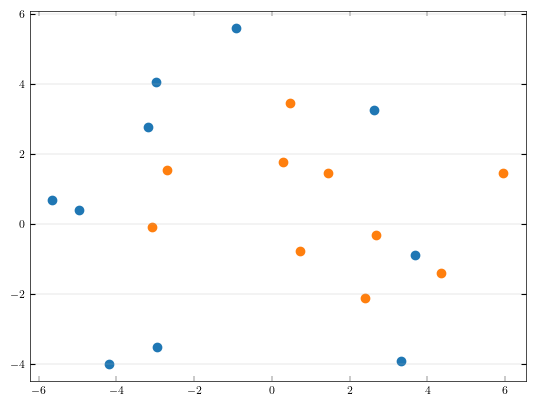

In [463]:
from ott.geometry import pointcloud, geometry

batch_size1 = 10
batch_size2 = 10

g1 = np.ones((batch_size1)) / batch_size1
g2 = np.ones((batch_size2)) / batch_size2

x0 = sample_8gaussians(batch_size1)
x1 = sample_moons(batch_size2)

plt.scatter(x0[:,0], x0[:,1])
plt.scatter(x1[:,0], x1[:,1])
plt.show()

C = torch.from_numpy(distance.cdist(x0, x1)).to(device)
# We recommended normalizing input distance matrices by the max-value for numerical stability and may make this a default.
C = C / C.max()

To run the method, simply call <tt>` FRLC.FRLC_opt `</tt> on the distance matrices used (e.g. $\mathbf{C}$ for the Wasserstein problem, $\mathbf{A}, \mathbf{B}$ for GW or in addition to $\mathbf{C}$ for FGW). You can toggle the type of optimization with the flag <tt>`Wasserstein=True`</tt> or <tt>`Wasserstein=False`</tt> and <tt>`FGW=True`</tt>. Additional flags <tt>`semiRelaxedLeft=True`</tt>, <tt>`semiRelaxedRight=True`</tt>, or <tt>`semiRelaxedRight=True`</tt> can be set to pick between standard relaxed OT problems. If all flags are False (default), then the OT run is balanced.

By default, we assume that the return is in the form $(\mathbf{Q}, \mathbf{R}, \mathbf{T})$ where one has access to the latent coupling $\mathbf{T}$ and the sub-couplings $\mathbf{Q}$ and $\mathbf{R}$ which map from the observed points to the latent points. Setting <tt>` returnFull = True `</tt> will return the full low-rank alignment matrix $\mathbf{P}$ instead.

In [310]:
P, errs = frlc.FRLC_opt(C, device=device, r=100, max_iter=20, returnFull=True, gamma=70, max_inneriters_balanced=500, max_inneriters_relaxed=500)

print(f'OT cost of FRLC: {(P * C).sum()}')

print(P.sum(axis=0))
print(P.sum(axis=1))
print(P.sum())
print(np.linalg.svd(P)[1])

Iteration: 0
OT cost of FRLC: 0.2286432504776783
tensor([0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100, 0.0100,
        0.0100], dtype=torch.float64)
tensor([0.0100, 0.0100, 0.0100, 0

In [ ]:
import convex_lrot as clrot
import importlib
import jax.numpy as jnp
importlib.reload(clrot)

# L, R, obj = clrot.solve_low_rank_ot_alternating_lp(C.cpu().numpy(), g1, g2, 10, 25)

P, obj = clrot.solve_nuclear_ot(
    jnp.asarray(C.cpu().numpy()),
    jnp.asarray(g1),
    jnp.asarray(g2),
    3,
    1.0 / (min(g1.shape[0], g2.shape[0])), # gamma \defeq max {||P||_\sigma : P \in \Pi_{a,b}}
    max_iter=1,
    tolerance=1e-6,
    epsilon=1e-4,
    verbose=True
)

#P, obj = clrot.solve_linear_ot_cvxpy(C.cpu().numpy(), g1, g2)
#print()
L_round, R_round, singular_values = clrot.nonnegative_rounding(P, g1, g2, 10, seed=4)
P_round = L_round @ R_round

print("C_frobenius:", torch.norm(C, p='fro'))
print("Convex Relaxation Lower Bound:", obj)
print("Convex Relaxation Upper Bound:", (C.cpu().numpy() * P_round).sum())
print("||P1 - g1||_1:", np.sum(np.abs(P_round.sum(axis=0) - g1)))
print("||1^TP - g2||_1:", np.sum(np.abs(P_round.sum(axis=1) - g2)))

2025-05-16 10:10:17.559 | INFO     | convex_lrot:solve_nuclear_ot_sinkhorn:187 - Time for Entropy Regularized OT: 0.1288437843322754
2025-05-16 10:10:17.562 | INFO     | convex_lrot:solve_nuclear_ot_sinkhorn:188 - Linear Objective (P1): 0.23285561800003052


Q-step Objective Cost: 2.1598410606384277
Linear Objective Cost: 0.4927653670310974
Q-step Objective Cost: 2.169891119003296
Linear Objective Cost: 0.48783788084983826
Q-step Objective Cost: 2.179940938949585
Linear Objective Cost: 0.4829595386981964
Q-step Objective Cost: 2.189990758895874
Linear Objective Cost: 0.47812989354133606
Q-step Objective Cost: 2.2000410556793213
Linear Objective Cost: 0.47334861755371094
Q-step Objective Cost: 2.2100908756256104
Linear Objective Cost: 0.46861517429351807
Q-step Objective Cost: 2.2201406955718994
Linear Objective Cost: 0.4639289081096649
Q-step Objective Cost: 2.2301905155181885
Linear Objective Cost: 0.4592897295951843
Q-step Objective Cost: 2.2402405738830566
Linear Objective Cost: 0.45469680428504944
Q-step Objective Cost: 2.250290870666504
Linear Objective Cost: 0.4501497745513916
Q-step Objective Cost: 2.260340690612793
Linear Objective Cost: 0.44564831256866455
Q-step Objective Cost: 2.270390510559082
Linear Objective Cost: 0.441191703

KeyboardInterrupt: 

In [ ]:
print("Rank of P_round:", np.linalg.matrix_rank(P_round))

Rank of P_round: 10


(1000, 50)


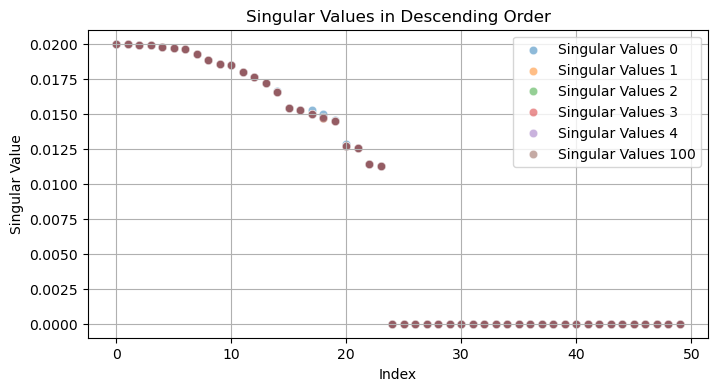

In [187]:
import seaborn as sns

print(singular_values.shape)

num_vals = 50

plt.figure(figsize=(8, 4))
for i in [0, 1, 2, 3, 4, 100]:
    sns.scatterplot(x=np.arange(num_vals), y=singular_values[i,:num_vals], label=f"Singular Values {i}", alpha=0.5)

plt.title("Singular Values in Descending Order")
plt.xlabel("Index")
#plt.yscale("log")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

/var/folders/89/fjbhcnqs1mj37h88z0mvdkc40000gn/T/ipykernel_76733/2004006251.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


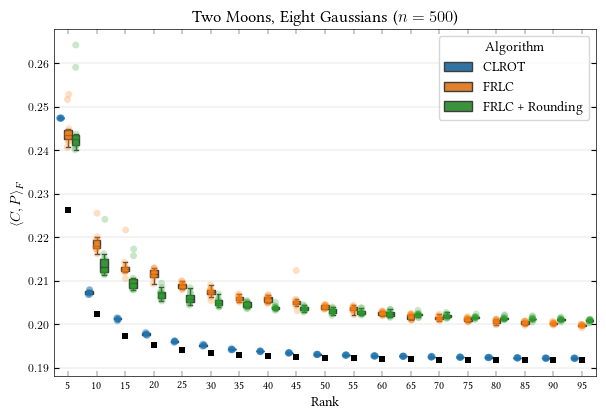

In [308]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("~/plotting/paper.mplstyle")

df = pd.read_csv("../merged_results.csv")
algo_rename_map = {
    "clrot": "CLROT",
    "frlc": "FRLC",
    "frlcround": "FRLC + Rounding"
}
df['algorithm'] = df['algorithm'].replace(algo_rename_map)
lower_bounds = df[~df['lower_bound'].isna()][['rank', 'lower_bound', 'algorithm']].drop_duplicates()

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.stripplot(
    data=df[(df['rank'] > 1) & (df['rank'] < 100)],
    x='rank',
    y='objective_cost',
    hue='algorithm',
    dodge=True,
    alpha=0.25,
    ax=ax,
    legend=False,
)
sns.boxplot(
    data=df[(df['rank'] > 1) & (df['rank'] < 100)],
    x='rank',
    y='objective_cost',
    hue='algorithm',
    showfliers=False,
    ax=ax,
    legend=True
)
# add lower bound using ax.scatter (avoid using hue and linestyle in sns.scatterplot)
lower_bounds_filtered = lower_bounds[(lower_bounds['rank'] > 1) & (lower_bounds['rank'] < 100)]
sns.stripplot(
    data=lower_bounds_filtered,
    x='rank',
    y='lower_bound',
    color='black',
    marker='s',
    label='Lower Bound',
    ax=ax
)


# Remove duplicate legend entries by keeping only the first set
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:len(algo_rename_map)], labels[0:len(algo_rename_map)], title="Algorithm")
ax.set_title("Two Moons, Eight Gaussians ($n = 500$)")
ax.set_xlabel("Rank")
ax.set_ylabel(r"$\langle C, P \rangle_F$")
#fig.legend(title="Algorithm")
fig.show()
fig.savefig("two_moons_eight_gaussians.pdf", bbox_inches='tight')